In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [7]:
df = pd.read_csv('height-weight.csv')

In [8]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

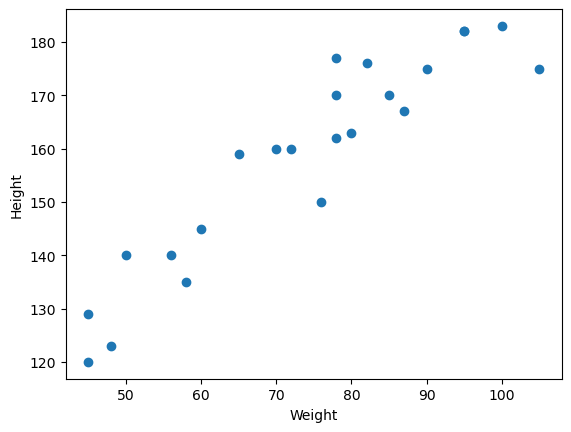

In [9]:
##Scatter plot
plt.scatter(df['Weight'] , df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [10]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


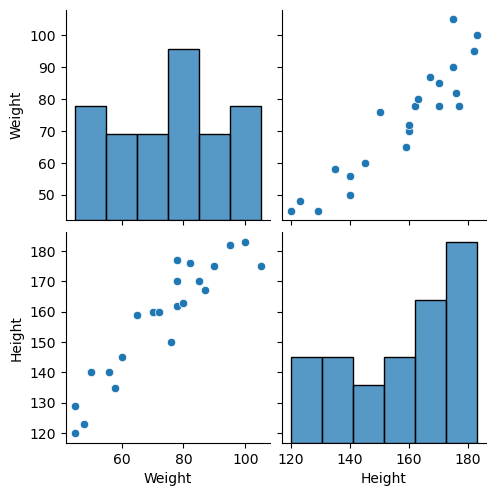

In [11]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [12]:
## Independent and dependent features
X = df[['Weight']] #Adding an additional bracket[] makes it a DataFrame else it will be Series
y = df[['Height']] # This can be in series and 1D array form

## We have to make sure that our independent feature should be in dataframe or 2D array

In [13]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [14]:
X_series= df['Weight']
np.array(X_series).shape
#   We can see that it has only 23 rows no columns are mentioned


(23,)

In [15]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [16]:
## Train Test Split
from sklearn.model_selection import train_test_split


In [17]:
X_train , X_test , y_train , y_test = train_test_split (X,y, test_size= 0.25,random_state=42)

In [18]:
X_train.shape

(17, 1)

In [19]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(np.array(X_train))# where mean = 0 and std = 1

In [21]:
#To prevent DATA LEAKAGE (as i do not want my training data to know anything about my test data)... we use only transform for X_test..

In [22]:
X_test_= scaler.transform(np.array(X_test)) # can be done without np.array but we got a warning so we go with this method

In [23]:
# Check your actual y_train values
print(y_train[:5])  # Look at these numbers

    Height
1      135
13     183
5      162
2      123
11     182


In [ ]:
# Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [25]:
regression = LinearRegression(n_jobs = -1)
# The n_jobs = -1 parameter in LinearRegression() tells scikit-learn to use all available CPU cores for parallel computation, 
# making the training faster on multi-core processors.

In [26]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [27]:
print("Coefficient or slope : ", regression.coef_) # tell that one unit movement in indept value leads to this much change in dept value
print("Intercept : ", regression.intercept_) # value of indept when dept is zero

Coefficient or slope :  [[17.2982057]]
Intercept :  [156.47058824]


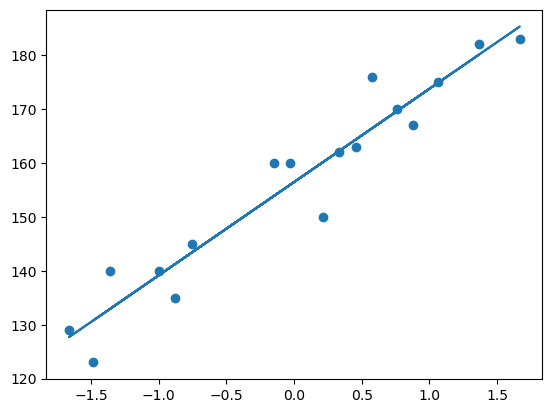

In [ ]:
# plot Training data plot best fit line
plt.scatter(X_train ,y_train)
plt.plot(X_train , regression.predict(X_train))


### Prediction of test data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_test = 156.470 + 17.29(X_test)

In [29]:
## Prediction for test data
y_pred = regression.predict(X_test_)

In [ ]:
## Performace Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [31]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)    
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228689
9.665125886795009
10.716374991212602


### R sqaure
Formula

**R^2 = 1-SSR/SST**

R^2 = coefficient of determination
SSR = sum of squares of residuals
SST = total sum of squares

In [ ]:
from sklearn.metrics import r2_score

In [33]:
score = r2_score(y_test,y_pred)
print(score)

0.7360826717981278


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [34]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476598

In [35]:
## OLS Linear Regression
import statsmodels.api as sm

In [37]:
model = sm.OLS(y_train,X_train).fit()

In [43]:
prediciton = model.predict(X_test)
print(prediciton)

15    1349.260045
9     1349.260045
0      778.419257
8     1643.329542
17    1124.383371
12    1816.311599
dtype: float64


In [45]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 18 Apr 2026   Prob (F-statistic):                       0.664
Time:                        18:27:01   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/usr/lib/python3/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [48]:
## Predicition of new data
regression.predict(scaler.transform([[72]])) ## happening beacuse we miss the part where we do standardization

array([[155.97744705]])